# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---

## Case: Discovering Hidden Themes in Airbnb Reviews
**Dataset:** Inside Airbnb – Asheville Reviews

---

In this notebook, we’ll apply **topic modeling** to uncover common themes in Airbnb guest reviews.  
Topic modeling helps us understand what guests frequently mention — without manually reading thousands of reviews.

We’ll identify hidden patterns such as:
- **Cleanliness and comfort**
- **Host communication**
- **Neighborhood and location**
- **Amenities and experience**

**Goal:** Learn how to extract and interpret latent themes using multiple topic modeling techniques.

## Topic Modeling Workflow

The overall process includes:

1. **Load and Preprocess** Airbnb review text data  
tokenization, stopword removal, lemmatization)  
2. **Convert text to numeric form** (Bag-of-Words or TF-IDF)  
3. **Traditional Topic Modeling Approaches** (LDA, NMF, LSA)
4. **Modern Topic Modeling with BERTopic**   
5. **Visualize results** for easier interpretation
6. **Interpret and label** the discovered topics

> This notebook builds directly on the preprocessing techniques introduced in **Week 6 (NLP Foundations)**.


## Step 1: Load Data and Text Preprocessing (Review from Week 6)

Before we can perform topic modeling, the text must be cleaned and converted into a machine-readable format.

We’ll reuse the same steps as in Week 6:
- Lowercasing and removing punctuation  
- Tokenizing text  
- Removing stopwords  
- Lemmatizing words  
- Building **Bag-of-Words** and **TF-IDF** matrices  

> These vectorized representations will serve as input for traditional topic models like **LDA, NMF, and LSA**.

**1.1 Import Libraries and Load Data**

In [36]:
# Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

In [37]:
# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:
# import Ashville reviews datasets
reviews_url = 'https://data.insideairbnb.com/united-states/nc/asheville/2024-06-21/data/reviews.csv.gz'

# Load the datasets into DataFrames
reviews_df = pd.read_csv(reviews_url, compression='gzip')

In [39]:

# Display the first few rows of each dataset
reviews_df.head()


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,155305,409437,2011-07-31,844309,Jillian,We had a wonderful time! The cottage was very ...
1,155305,469775,2011-08-23,343443,Katie,Place was great! Can't really speak to the ins...
2,155305,548257,2011-09-19,1152025,Katie,We had a great time! The cabin was nice and a...
3,155305,671470,2011-10-28,1245885,Jason,Clean and comfortable room with everything you...
4,155305,1606327,2012-07-01,1891395,Craig,The cabin was solid for an overnight stay. It ...


In [40]:
#check the shape of the dataframe
reviews_df.shape

(331718, 6)

**1.2 Text Clening Function**

We’ll define a reusable function that:
- Removes URLs, punctuation, and numbers
- Convert to lower case  
- Tokenizes text and removes stopwords  
- Lemmatizes each word to its root form

This produces cleaner, more consistent text for modeling.

In [41]:
# pre- processing function

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isnull(text):
        return ''
    # Remove URLs, non-letters, and convert to lowercase
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()

    # Tokenize and remove stopwords - word_tokenize() would be more accurate but slow
    tokens = text.split()
    stop_words = set(stopwords.words('english'))

    # Lemmatize and remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word not in string.punctuation]

    return ' '.join(tokens)

**1.3 Filter and Preprocess Reviews**

We now apply the `preprocess_text()` function to clean each review comment.  
To avoid performance issues, we’ll work with a **sample of 10,000 reviews** from 2019.  
This keeps our analysis representative but much faster to run.

> ⚠️ Note: We use `.copy()` to avoid the `SettingWithCopyWarning` from pandas when modifying sliced data.



In [42]:
# Ensure the 'date' column is in datetime format
reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')

# Filter only reviews from the year 2019
filtered_reviews = reviews_df[(reviews_df['date'].dt.year == 2023)].copy()


In [43]:
filtered_reviews.shape

(65409, 6)

In [44]:
# pre-process comments
filtered_reviews ['cleaned_comments'] = filtered_reviews ['comments'].apply(preprocess_text)

In [45]:
# Optional: Sample 10,000 reviews for faster processing
filtered_reviews = filtered_reviews.sample(n=10000, random_state=42)
filtered_reviews.shape


(10000, 7)

In [46]:
filtered_reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cleaned_comments
315917,674758651803723764,891364727014872638,2023-05-14,433743715,Holly,This house was a dream!!! I hope we will be ab...,house dream hope able get next time visit ashe...
298743,53295582,984138549320349172,2023-09-19,250045142,Michael And Leigh,Great place to stay!,great place stay
300645,628106526015180657,893487802247992804,2023-05-17,7387297,Lydia,This little cottage is adorable and was perfec...,little cottage adorable perfect stay asheville...
102866,18375617,1029766445052575796,2023-11-21,40541768,Anna,We really enjoyed our stay in Ashville and a b...,really enjoyed stay ashville big reason great ...
309969,686055814693911306,977526197456142392,2023-09-10,58233394,Suzana,Our stay was sweet and short. The location is ...,stay sweet short location perfect place well a...


## Step 2: Convert Text to Numeric Form (Bag-of-Words or TF-IDF)

**Vectorization Choices**

We represent each review as numeric features using **Bag-of-Words (BoW)** or **TF–IDF**.

- **BoW** favors frequent words (counts how often each term appears).  
- **TF–IDF** downweights ubiquitous terms that appear in many reviews, highlighting distinctive ones.

We’ll compare which representation yields more interpretable topics.

**Key Parameters**
- `min_df = 5` → ignore very rare tokens (appear in fewer than 5 documents)  
- `max_df = 0.9` → ignore very common tokens (appear in > 90 % of documents)  
- `stop_words = 'english'` → remove common English words (e.g., *the*, *and*, *is*)  
- `max_features = 5000` *(optional)* → cap the vocabulary to speed up modeling  
- `ngram_range = (1, 1)` → unigrams only (try `(1, 2)` later for unigrams + bigrams)




In [47]:
# Vectorize the cleaned comments (Bag-of-Words)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS # Import ENGLISH_STOP_WORDS


# Create a set of the default English stopwords
my_stop_words = set(ENGLISH_STOP_WORDS)

# Add your own custom stopwords to the set
custom_words = [
    "great", "place", "stay", "asheville", "nice",
    "really", "good", "well", "like", "us", "get", "got",
    "one", "time", "would", "definitely", "highly", "recommend",
    "also", "even", "made", "everything", "perfect"
]
my_stop_words.update(custom_words)

vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.90,
    stop_words=list(my_stop_words),
    max_features=5000,       # <- keep models fast
    ngram_range=(1, 1)       # <- change to (1, 2) to include bigrams
)

X_bow = vectorizer.fit_transform(filtered_reviews['cleaned_comments'])
feature_names = vectorizer.get_feature_names_out()

print("BoW matrix shape:", X_bow.shape)

BoW matrix shape: (10000, 2548)


In [48]:
# Vectorize the cleaned comments (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.90,
    stop_words=list(my_stop_words),
    max_features=5000,
    ngram_range=(1, 1)
)

# This creates the TF-IDF matrix directly
X_tfidf = tfidf_vectorizer.fit_transform(filtered_reviews['cleaned_comments'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (10000, 2548)


In [49]:
# Define functions to create plots

import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

# Function to plot the top words for each topic
def plot_top_words(model, feature_names, n_top_words=10, title='Top words per topic'):
    fig, axes = plt.subplots(1, model.n_components, figsize=(15, 5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx+1}', fontdict={'fontsize': 10})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=10)
    plt.suptitle(title, fontsize=12)
    plt.subplots_adjust(top=0.85, wspace=0.3)
    plt.show()


# Function to generate word clouds for each topic
def plot_word_clouds(model, feature_names, n_top_words=30):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = {feature_names[i]: topic[i] for i in top_features_ind}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_features)
        plt.figure()
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {topic_idx+1} Word Cloud', fontsize=16)
        plt.show()

## Step 3: Traditional Topic Modeling Approaches

We’ll begin with three classical approaches that use Bag-of-Words or TF-IDF representations.

### 1. Latent Dirichlet Allocation (LDA)
- Treats each document as a mixture of topics.  
- Each topic is represented as a distribution of words.  
- Helps discover *interpretable themes* in text.

### 2. Non-negative Matrix Factorization (NMF)
- Decomposes the TF-IDF matrix into smaller components.  
- Each component (topic) is described by the top keywords.  
- Works well for short and interpretable topics.

### 3. Latent Semantic Analysis (LSA)
- Uses **Singular Value Decomposition (SVD)** to identify underlying structures in text data.  
- Captures broader word associations but can be harder to interpret.



Both **Bag-of-Words (BoW)** and **TF–IDF** representations are included below. Use **only one** for modeling — comment out the other line before running.

> *Tip:* Start with **BoW** for easier interpretation, then try **TF–IDF** to see how topic quality changes.


**1) Latent Dirichlet Allocation (LDA)**


In [50]:
# Set the number of topics (trying out three different number of topics)
# n_topics = 3
n_topics = 7
# n_topics = 10

# Create and fit the LDA model
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_model.fit(X_bow)
#lda_model.fit(X_tfidf)

# Extract the top words from each topic
terms = vectorizer.get_feature_names_out()
lda_topics = {}

for index, topic in enumerate(lda_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lda_topics[f"Topic {index+1}"] = top_words

# Print the LDA topics
print("LDA Topics:")
for topic, words in lda_topics.items():
    print(f"{topic}: {', '.join(words)}")



LDA Topics:
Topic 1: clean, location, close, downtown, comfortable, host, quiet, super, neighborhood, area
Topic 2: bed, kitchen, comfortable, house, room, space, bathroom, clean, home, bedroom
Topic 3: host, home, wonderful, dog, loved, clean, airbnb, responsive, stayed, little
Topic 4: host, location, house, clean, easy, responsive, check, issue, instruction, didnt
Topic 5: beautiful, home, loved, view, enjoyed, house, hot, tub, amazing, location
Topic 6: spot, night, location, space, walking, weekend, area, restaurant, parking, downtown
Topic 7: location, downtown, clean, walk, exactly, easy, described, walking, restaurant, close


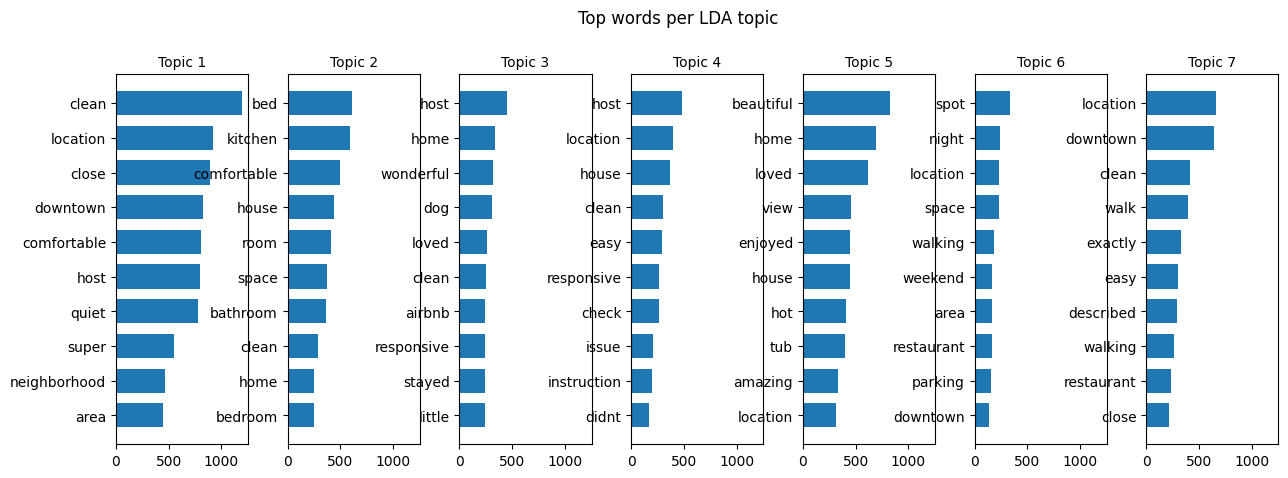

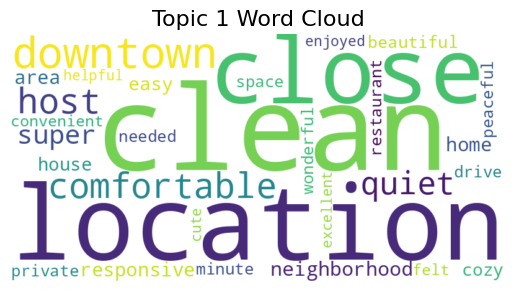

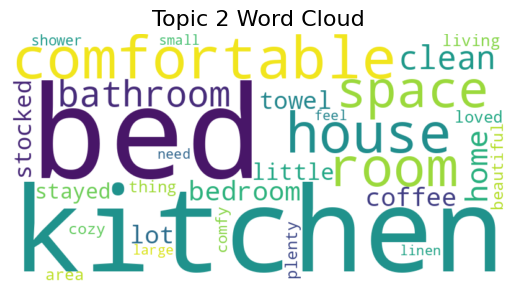

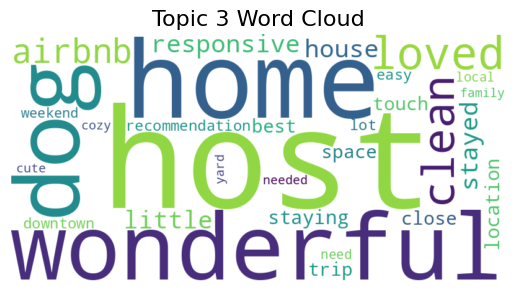

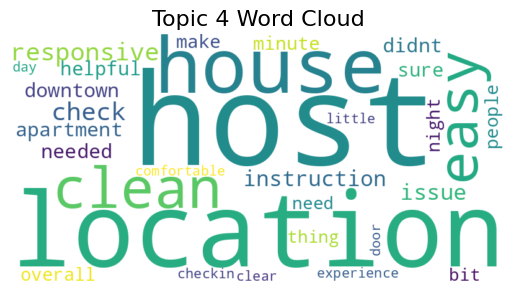

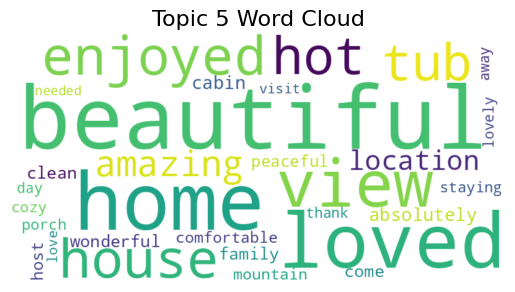

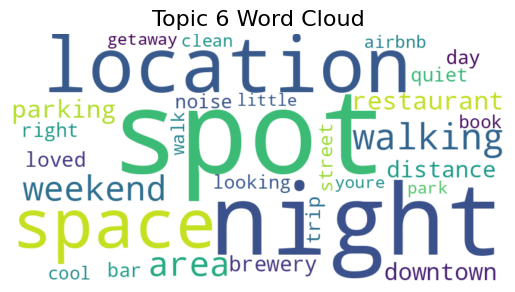

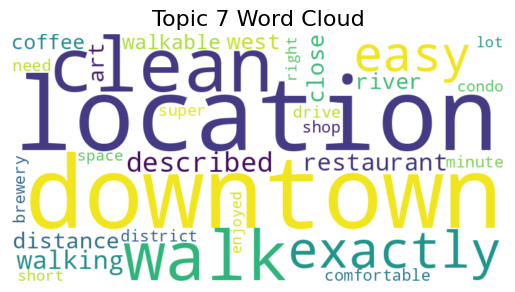

In [51]:
# LDA topic plots
plot_top_words(lda_model, terms, n_top_words=10, title='Top words per LDA topic')
plot_word_clouds(lda_model, terms)

**2)  Non-negative Matrix Factorization (NMF)**

In [52]:


# Create and fit the NMF model
nmf_model = NMF(n_components=n_topics, random_state=42)
#nmf_model.fit(X_tfidf)
nmf_model.fit(X_bow)

# Extract the top words from each topic
nmf_topics = {}

for index, topic in enumerate(nmf_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    nmf_topics[f"Topic {index+1}"] = top_words

# Print the NMF topics
print("NMF Topics:")
for topic, words in nmf_topics.items():
    print(f"{topic}: {', '.join(words)}")

NMF Topics:
Topic 1: downtown, close, easy, minute, drive, restaurant, quiet, walk, area, walking
Topic 2: location, convenient, apartment, restaurant, excellent, wonderful, parking, walking, walkable, beautiful
Topic 3: house, loved, family, view, room, hot, kitchen, tub, beautiful, minute
Topic 4: clean, super, comfortable, quiet, needed, cozy, responsive, spacious, extremely, close
Topic 5: host, responsive, wonderful, helpful, friendly, beautiful, airbnb, amazing, super, excellent
Topic 6: home, beautiful, felt, away, right, feel, loved, view, peaceful, family
Topic 7: comfortable, space, bed, loved, kitchen, room, area, lot, coffee, bathroom


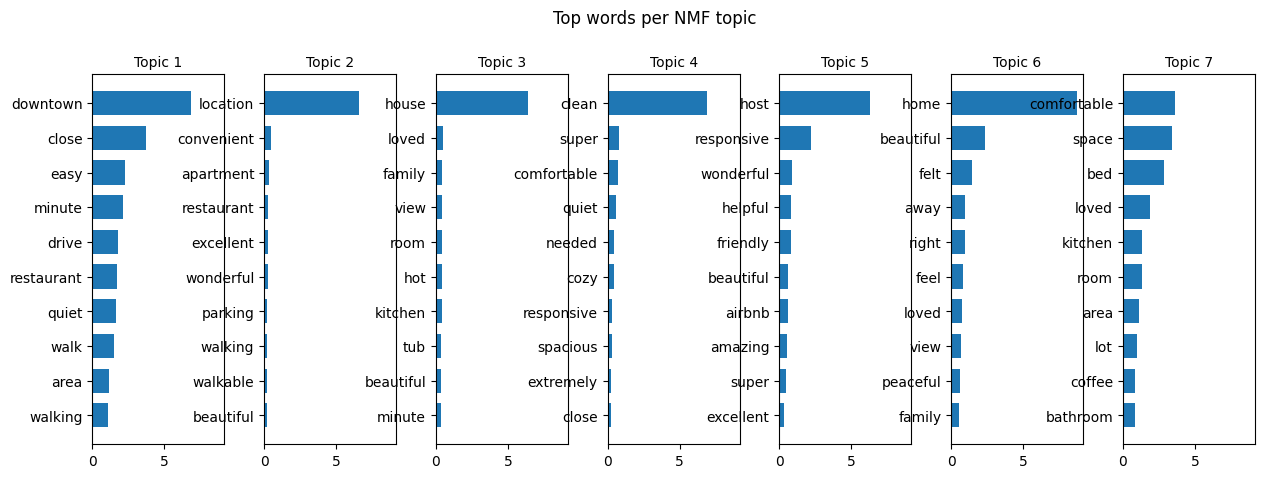

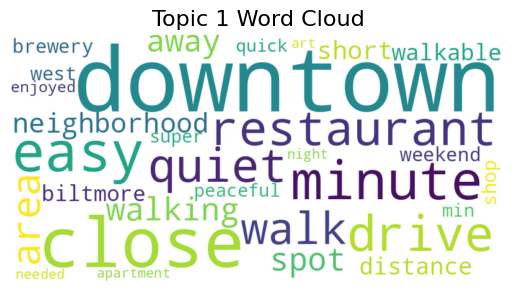

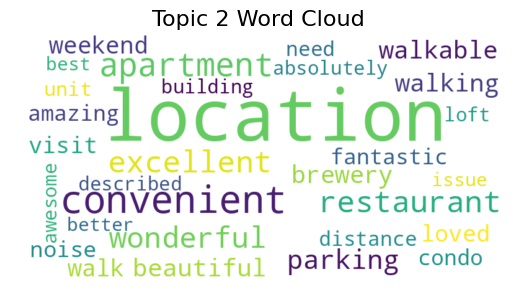

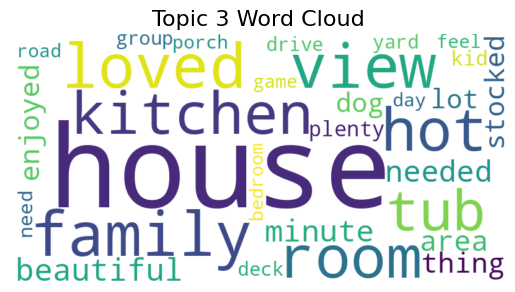

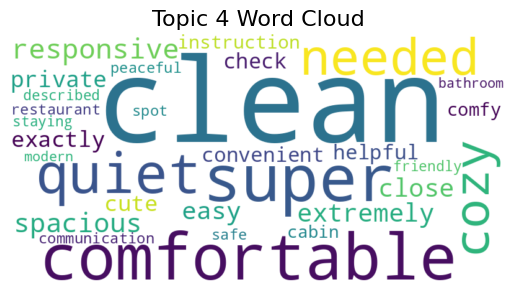

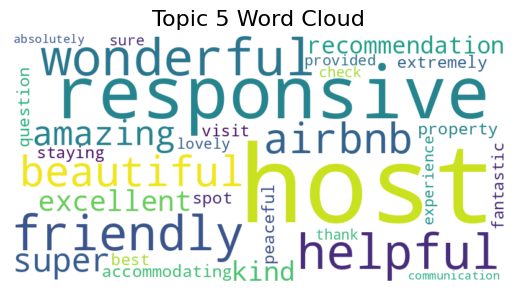

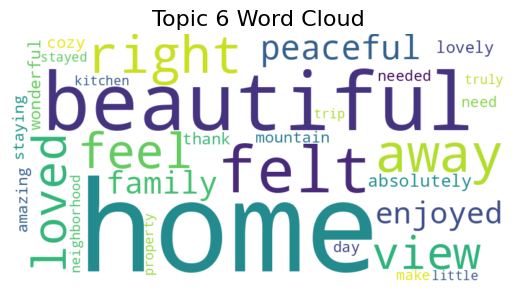

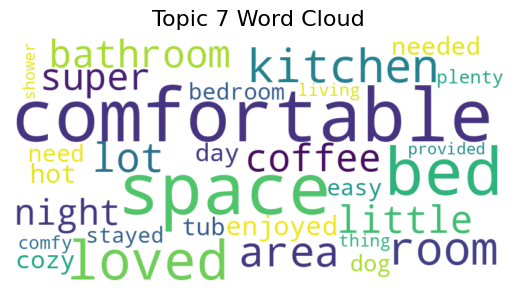

In [53]:
# NMF topic plots

plot_top_words(nmf_model, terms, n_top_words=10, title='Top words per NMF topic')
plot_word_clouds(nmf_model, terms)

**3) Latent Semantic Analysis (LSA)**

In [54]:
#Fit the LSA model
lsa_model = TruncatedSVD(n_components=n_topics, random_state=42)
#lsa_model.fit(X_tfidf)
lsa_model.fit(X_bow)

# Extract the top words for each topic
terms = vectorizer.get_feature_names_out()
lsa_topics = {}

for index, topic in enumerate(lsa_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lsa_topics[f"Topic {index+1}"] = top_words

# Print the LSA topics
print("LSA Topics:")
for topic, words in lsa_topics.items():
    print(f"{topic}: {', '.join(words)}")

LSA Topics:
Topic 1: clean, location, house, home, host, downtown, comfortable, space, close, loved
Topic 2: location, downtown, clean, close, restaurant, walk, easy, apartment, walking, quiet
Topic 3: house, downtown, room, minute, close, hot, location, tub, group, bedroom
Topic 4: clean, comfortable, bed, space, super, bathroom, quiet, kitchen, cozy, room
Topic 5: host, clean, responsive, location, wonderful, helpful, friendly, super, excellent, amazing
Topic 6: location, clean, home, house, comfortable, felt, convenient, beautiful, stocked, condo
Topic 7: clean, downtown, close, host, responsive, home, quiet, drive, minute, easy


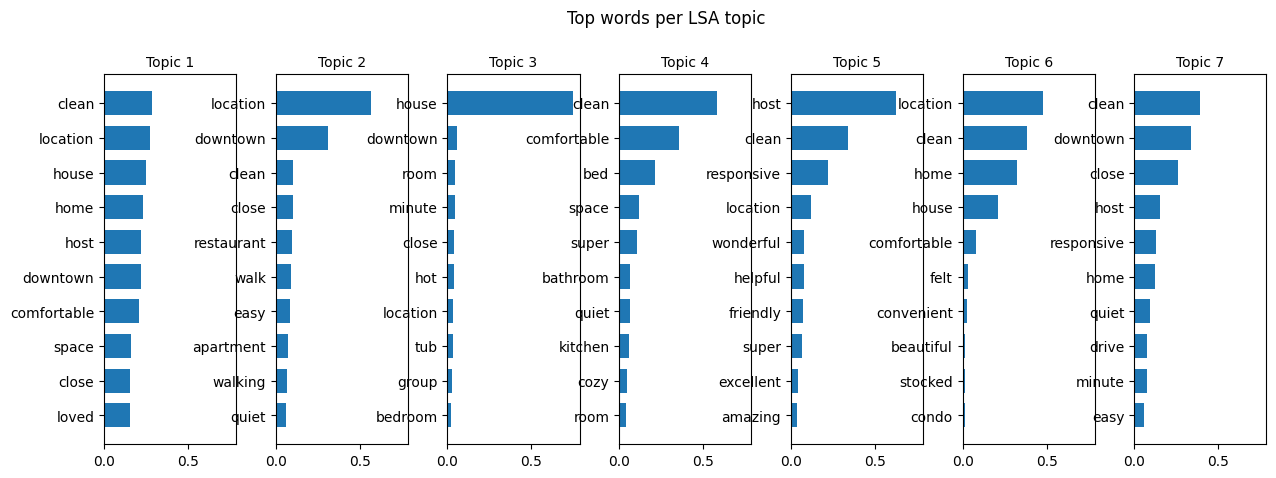

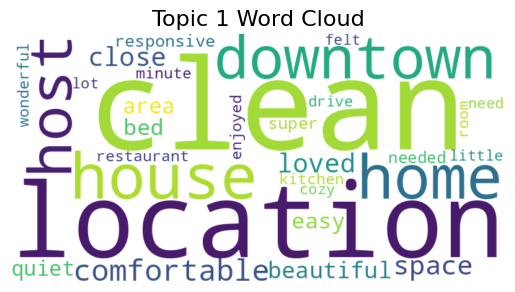

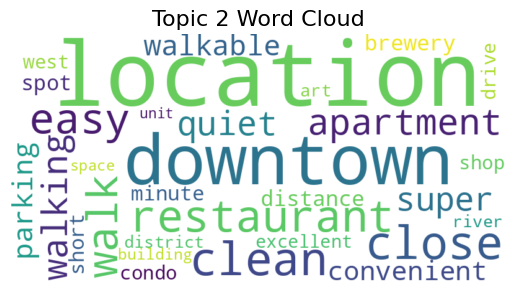

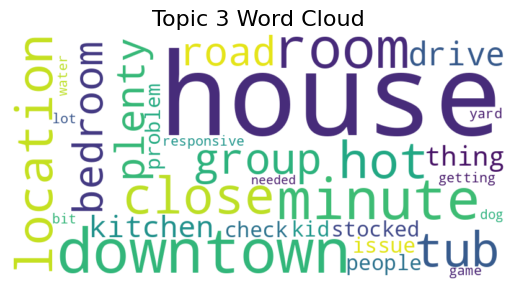

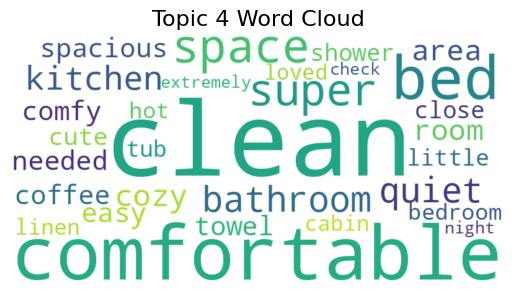

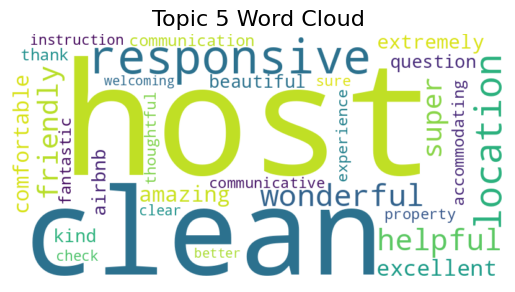

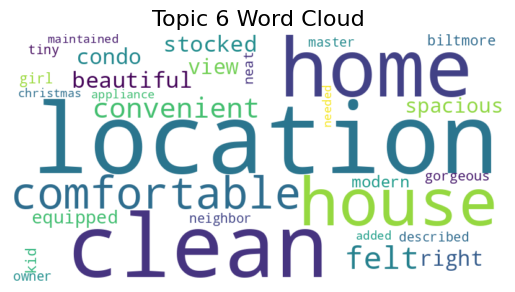

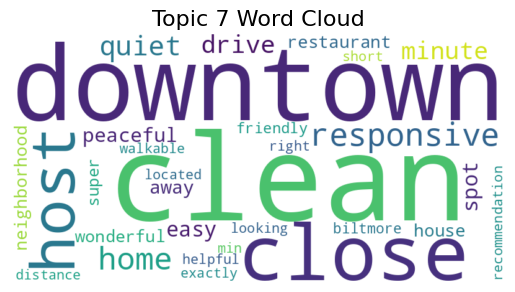

In [55]:
# LSA Topic Plots
plot_top_words(lsa_model, terms, n_top_words=10, title='Top words per LSA topic')
plot_word_clouds(lsa_model, terms)



**Topic Distance**

In [56]:
#Let's check the topic distance

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Function to plot topic distances using PCA
def plot_topic_distance_pca(model, title='Topic Distance (PCA)'):
    # Get the topic-word matrix (components_) from the model
    topic_word_matrix = model.components_

    # Apply PCA to reduce the topic-word matrix to 2 dimensions
    pca = PCA(n_components=2)
    topic_pca = pca.fit_transform(topic_word_matrix)

    # Plot the topics in 2D space
    plt.figure(figsize=(8, 6))
    plt.scatter(topic_pca[:, 0], topic_pca[:, 1], c='blue', edgecolor='k', s=100)

    # Annotate the topics with text labels
    for i in range(len(topic_pca)):
        plt.text(topic_pca[i, 0], topic_pca[i, 1], f'Topic {i+1}', fontsize=12)

    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

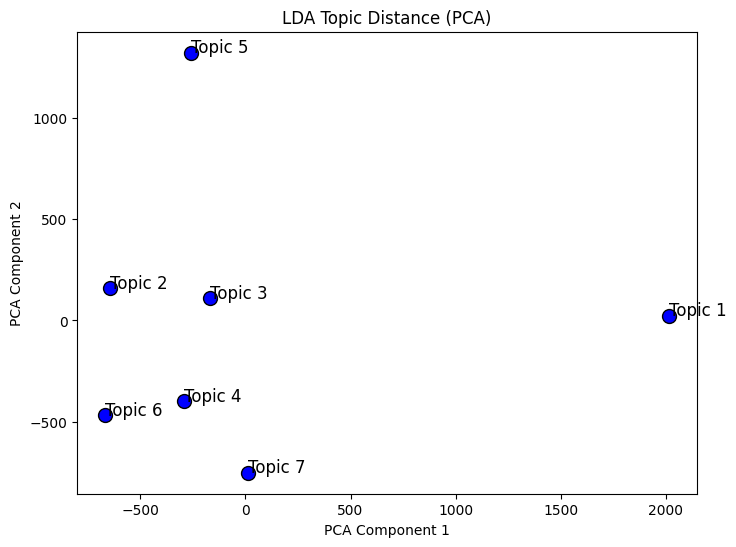

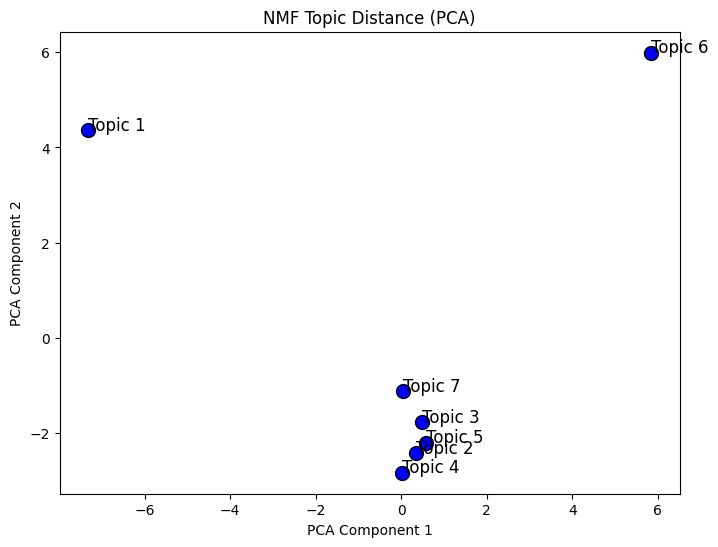

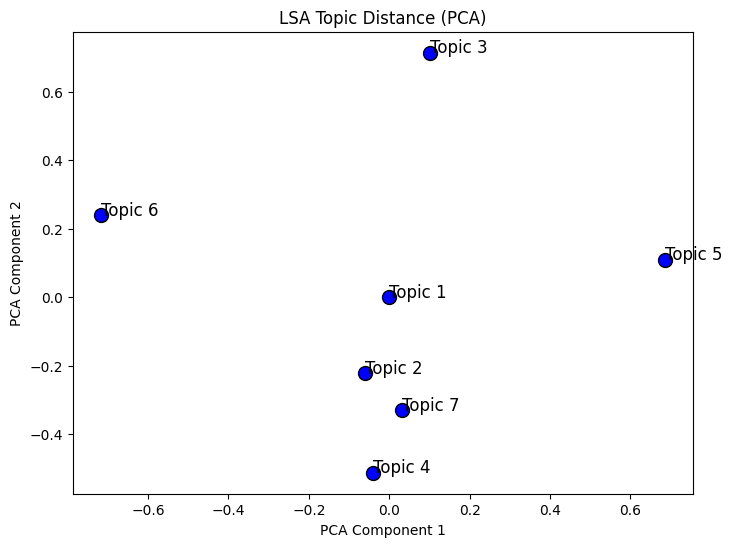

In [57]:
# compare topic distance of all models

# LDA
plot_topic_distance_pca(lda_model, title='LDA Topic Distance (PCA)')
# NMF
plot_topic_distance_pca(nmf_model, title='NMF Topic Distance (PCA)')
# LSA
plot_topic_distance_pca(lsa_model, title='LSA Topic Distance (PCA)')


## Step 3: Modern Topic Modeling with BERTopic

**BERTopic** represents a more advanced, context-aware approach to topic modeling.  
It combines **transformer embeddings (e.g., BERT)** with clustering techniques to discover topics that reflect the true *semantic meaning* of text.

Key ideas:
- Each document is converted into a **dense vector embedding**.  
- Clustering groups semantically similar reviews together.  
- Topics are extracted based on representative terms.

**Advantages:**
- Understands synonyms and context (e.g., *“clean”*, *“tidy”*).  
- Produces coherent and meaningful topics.  
- Doesn’t require specifying the number of topics upfront.
- Can handle both raw and cleaned text — but using cleaned text often yields more focused topics, especially for longer reviews or detailed narratives.
- For shorter or more casual texts (like tweets or messages with emojis, punctuation, or stylistic tone), keeping the raw text may preserve subtle emotional or expressive cues that embeddings can interpret.

**Available Pre-trained Models:**
You can find various pre-trained models on Hugging Face’s model hub, such as:

*   BERT (bert-base-uncased)
*   RoBERTa (roberta-base)
*   DistilBERT (distilbert-base-nli-stsb-mean-tokens)
*   Sentence-BERT (all-MiniLM-L6-v2, paraphrase-MiniLM-L12-v2, etc.)


BERTopic uses "all-MiniLM-L6-v2" by default, a lightweight sentence transformer model. You can use any pre-trained transformer model by loading it via SentenceTransformer and passing it to BERTopic.


e.g.,

*from sentence_transformers import SentenceTransformer*

*custom_embedding_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')*



In [58]:
!pip install bertopic

In [59]:
from bertopic import BERTopic

# Let's sample a small subset of data for the class demostration purpose. If you use it in the assignment, please use the full dataset.
sampled_reviews = filtered_reviews.sample(n=500, random_state=42)

# Prepare the text data for BERTopic
texts = sampled_reviews['cleaned_comments'].tolist()

# Fit the BERTopic model
topic_model = BERTopic()
topics, probabilities = topic_model.fit_transform(texts)

# Get topic information
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic  Count                               Name  \
0     -1    153           -1_stay_great_place_host   
1      0    192           0_great_stay_place_would   
2      1     96       1_asheville_stay_place_great   
3      2     26  2_host_great_welcoming_responsive   
4      3     18  3_stay_wonderful_great_experience   
5      4     15       4_host_asheville_great_place   

                                      Representation  \
0  [stay, great, place, host, location, would, as...   
1  [great, stay, place, would, clean, home, every...   
2  [asheville, stay, place, great, downtown, perf...   
3  [host, great, welcoming, responsive, place, st...   
4  [stay, wonderful, great, experience, staying, ...   
5  [host, asheville, great, place, location, clea...   

                                 Representative_Docs  
0  [great private place stay perfect size spot tw...  
1  [molly place perfect stay good location close ...  
2  [great stay beautiful neighborhood easy access...  
3  [grea

In [60]:
# Visualize the word distribution for the topics
topic_model.visualize_barchart()

In [61]:
# Visualize the hierarchical clustering of topics
topic_model.visualize_hierarchy()

In [62]:
# Visualize the topic similarity using a heatmap
topic_model.visualize_heatmap()

In [63]:
topic_model.visualize_topics()

## Reflection Exercise: Interpreting and Applying Topic Modeling Insights

Now that you’ve completed the topic modeling workflow, take a few minutes to reflect on your results.  
  

---

### Part 1: Model Interpretation
1. Compare the results from **LDA**, **NMF**, and **LSA**.  
   - Which model produced the most *interpretable* topics?  
   - How did the choice of **vectorization method** (BoW vs. TF–IDF) affect the results?  

2. For **BERTopic**, describe how its topics differed from traditional models.  
   - Were they more semantically meaningful or more specific?  
   - Did the model identify any subtle themes that others missed?  

---

### Part 2: Business Insights
1. Based on your topics, what are the **main themes** Airbnb guests care about (e.g., location, cleanliness, amenities, host interactions)?  

2. If you were advising Airbnb or local hosts, what **specific recommendations** would you make based on these insights?  

---

*Tip:* Keep your reflections concise but thoughtful — focus on interpreting the results rather than describing the steps.
